<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Scatter Plot**


Estimated time needed: **45** minutes


## Overview

In this lab, you will focus on creating and interpreting scatter plots to visualize relationships between variables and trends in the dataset. The provided dataset will be directly loaded into a pandas DataFrame, and various scatter plot-related visualizations will be created to explore developer trends, compensation, and preferences.



## Objectives


In this lab, you will:

- Create and analyze scatter plots to examine relationships between variables.

- Use scatter plots to identify trends and patterns in the dataset.

- Focus on visualizations centered on scatter plots for better data-driven insights.


## Setup: Working with the Database



**Install and import the required libraries**


In [1]:
!pip install pandas
!pip install matplotlib

import pandas as pd
import matplotlib.pyplot as plt

#### Step 1: Load the dataset


In [2]:
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

df = pd.read_csv(file_path)



### Task 1: Exploring Relationships with Scatter Plots



#### 1. Scatter Plot for Age vs. Job Satisfaction



Visualize the relationship between respondents' age (`Age`) and job satisfaction (`JobSatPoints_6`). Use this plot to identify any patterns or trends.




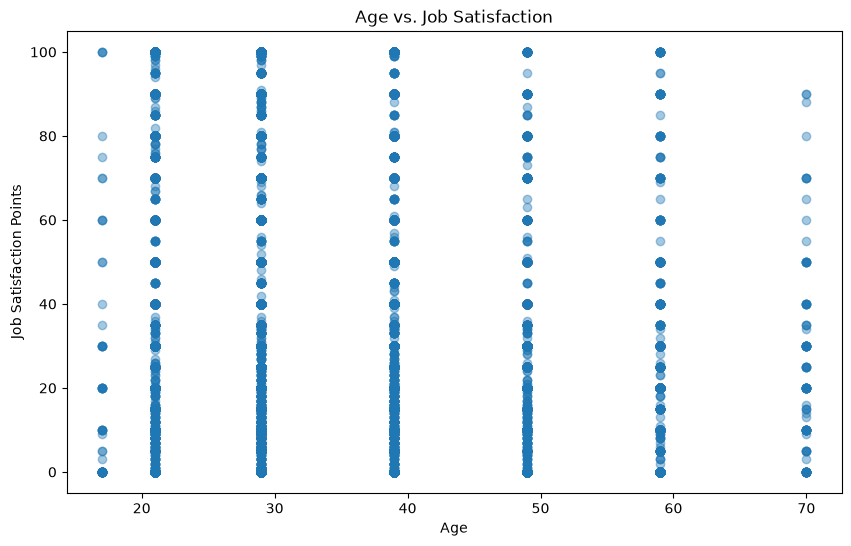

In [3]:
## Write your code here
# Convert Age groups to numeric representative values
age_mapping = {
    "Under 18 years old": 17,
    "18-24 years old": 21,
    "25-34 years old": 29,
    "35-44 years old": 39,
    "45-54 years old": 49,
    "55-64 years old": 59,
    "65 years or older": 70
}

df["Age_numeric"] = df["Age"].map(age_mapping)

# Convert Job Satisfaction to numeric
df["JobSatPoints_6"] = pd.to_numeric(
    df["JobSatPoints_6"],
    errors="coerce"
)

# Select required data
plot_data = df[
    ["Age_numeric", "JobSatPoints_6"]
].dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data["Age_numeric"],
    plot_data["JobSatPoints_6"],
    alpha=0.4
)

plt.title("Age vs. Job Satisfaction")
plt.xlabel("Age")
plt.ylabel("Job Satisfaction Points")

plt.show()

#### 2. Scatter Plot for Compensation vs. Job Satisfaction


Explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`) using a scatter plot.


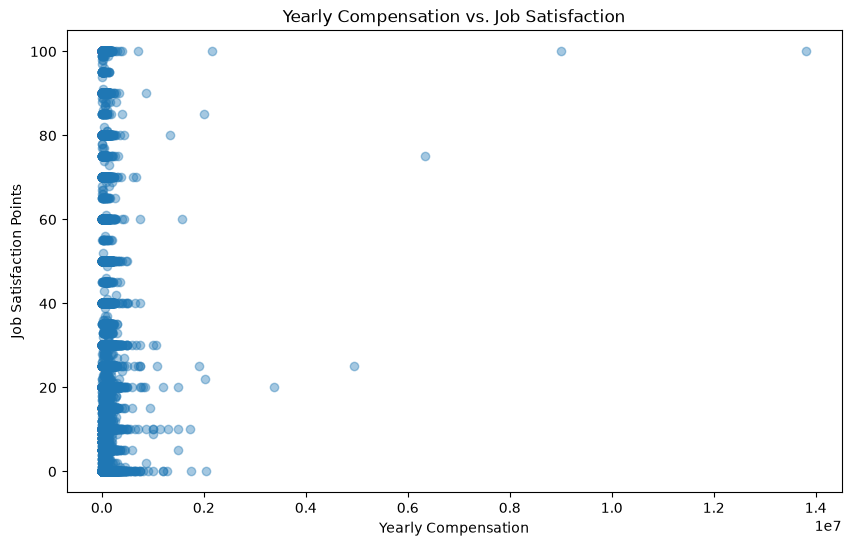

In [4]:
## Write your code here
# Convert columns to numeric
df["ConvertedCompYearly"] = pd.to_numeric(
    df["ConvertedCompYearly"],
    errors="coerce"
)

df["JobSatPoints_6"] = pd.to_numeric(
    df["JobSatPoints_6"],
    errors="coerce"
)

# Select required data
plot_data = df[
    ["ConvertedCompYearly", "JobSatPoints_6"]
].dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data["ConvertedCompYearly"],
    plot_data["JobSatPoints_6"],
    alpha=0.4
)

plt.title("Yearly Compensation vs. Job Satisfaction")
plt.xlabel("Yearly Compensation")
plt.ylabel("Job Satisfaction Points")

plt.show()

### Task 2: Enhancing Scatter Plots


#### 1. Scatter Plot with Trend Line for Age vs. Job Satisfaction



Add a regression line to the scatter plot of Age vs. JobSatPoints_6 to highlight trends in the data.


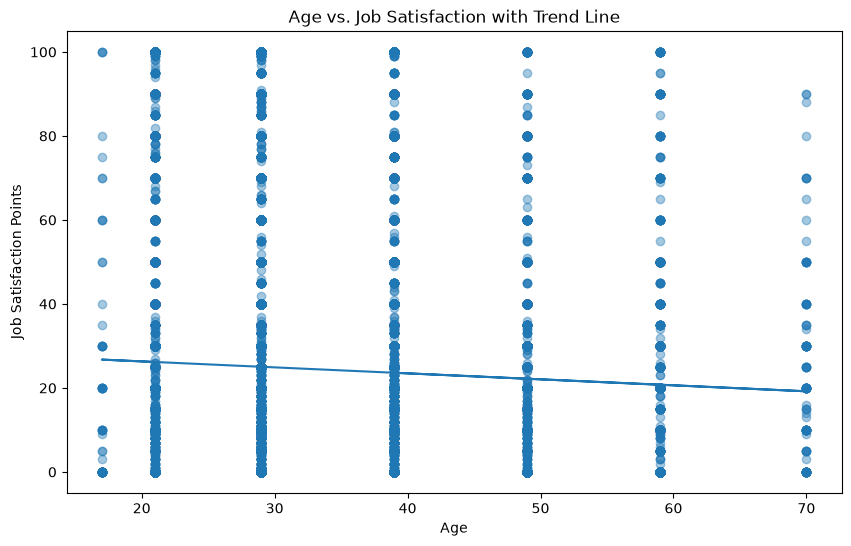

In [5]:
## Write your code here
import numpy as np

# Use the cleaned data from Task 1
plot_data = df[
    ["Age_numeric", "JobSatPoints_6"]
].dropna()

x = plot_data["Age_numeric"]
y = plot_data["JobSatPoints_6"]

# Calculate regression line
slope, intercept = np.polyfit(x, y, 1)

trend_line = slope * x + intercept

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    x,
    y,
    alpha=0.4
)

# Add regression line
plt.plot(
    x,
    trend_line
)

plt.title(
    "Age vs. Job Satisfaction with Trend Line"
)

plt.xlabel("Age")
plt.ylabel("Job Satisfaction Points")

plt.show()

#### 2. Scatter Plot for Age vs. Work Experience


Visualize the relationship between Age (`Age`) and Work Experience (`YearsCodePro`) using a scatter plot.


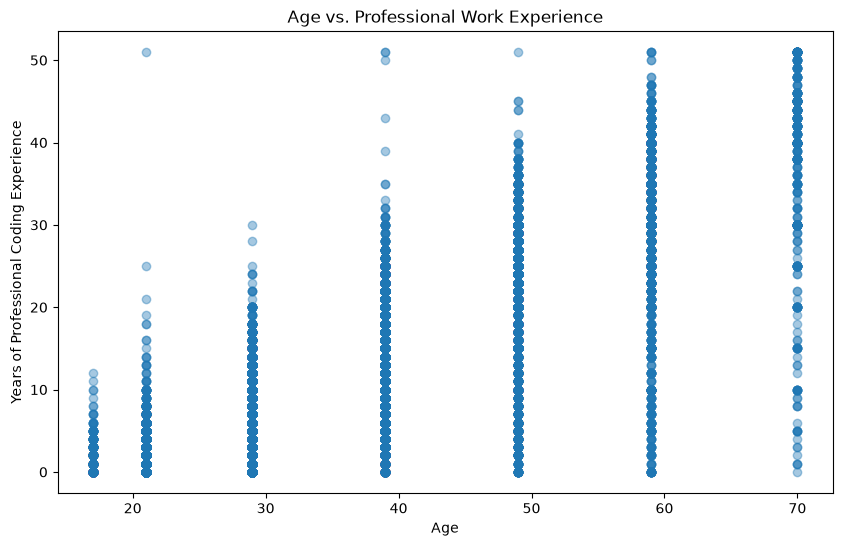

In [6]:
## Write your code here
# Convert YearsCodePro special values
df["YearsCodePro_numeric"] = (
    df["YearsCodePro"]
    .replace({
        "Less than 1 year": "0",
        "More than 50 years": "51"
    })
)

# Convert to numeric
df["YearsCodePro_numeric"] = pd.to_numeric(
    df["YearsCodePro_numeric"],
    errors="coerce"
)

# Select required data
plot_data = df[
    ["Age_numeric", "YearsCodePro_numeric"]
].dropna()

# Create scatter plot
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data["Age_numeric"],
    plot_data["YearsCodePro_numeric"],
    alpha=0.4
)

plt.title("Age vs. Professional Work Experience")
plt.xlabel("Age")
plt.ylabel("Years of Professional Coding Experience")

plt.show()

### Task 3: Combining Scatter Plots with Additional Features


#### 1. Bubble Plot of Compensation vs. Job Satisfaction with Age as Bubble Size



Create a bubble plot to explore the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), with bubble size representing age.


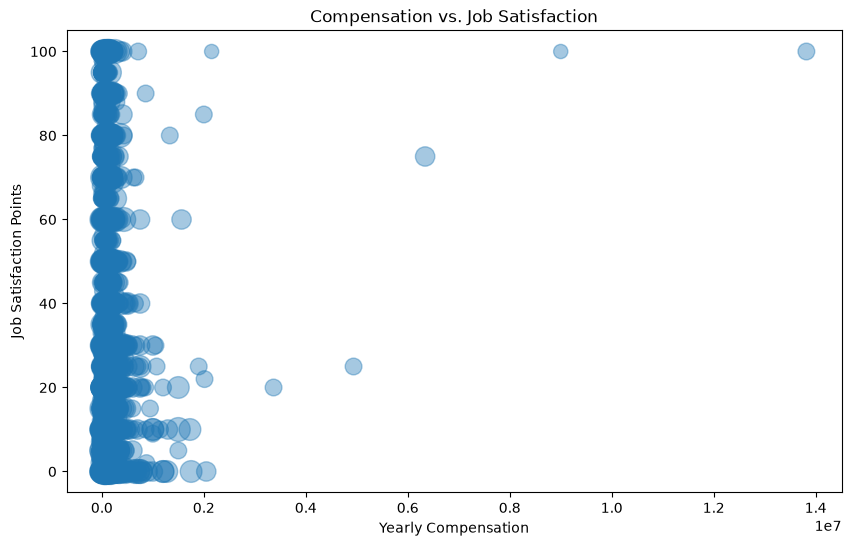

In [7]:
## Write your code here
# Select required columns
plot_data = df[
    [
        "ConvertedCompYearly",
        "JobSatPoints_6",
        "Age_numeric"
    ]
].dropna()

# Create bubble plot
plt.figure(figsize=(10, 6))

plt.scatter(
    plot_data["ConvertedCompYearly"],
    plot_data["JobSatPoints_6"],
    s=plot_data["Age_numeric"] * 5,
    alpha=0.4
)

plt.title(
    "Compensation vs. Job Satisfaction"
)

plt.xlabel("Yearly Compensation")
plt.ylabel("Job Satisfaction Points")

plt.show()

#### 2. Scatter Plot for Popular Programming Languages by Job Satisfaction


Visualize the popularity of programming languages (`LanguageHaveWorkedWith`) against job satisfaction using a scatter plot. Use points to represent satisfaction levels for each language.


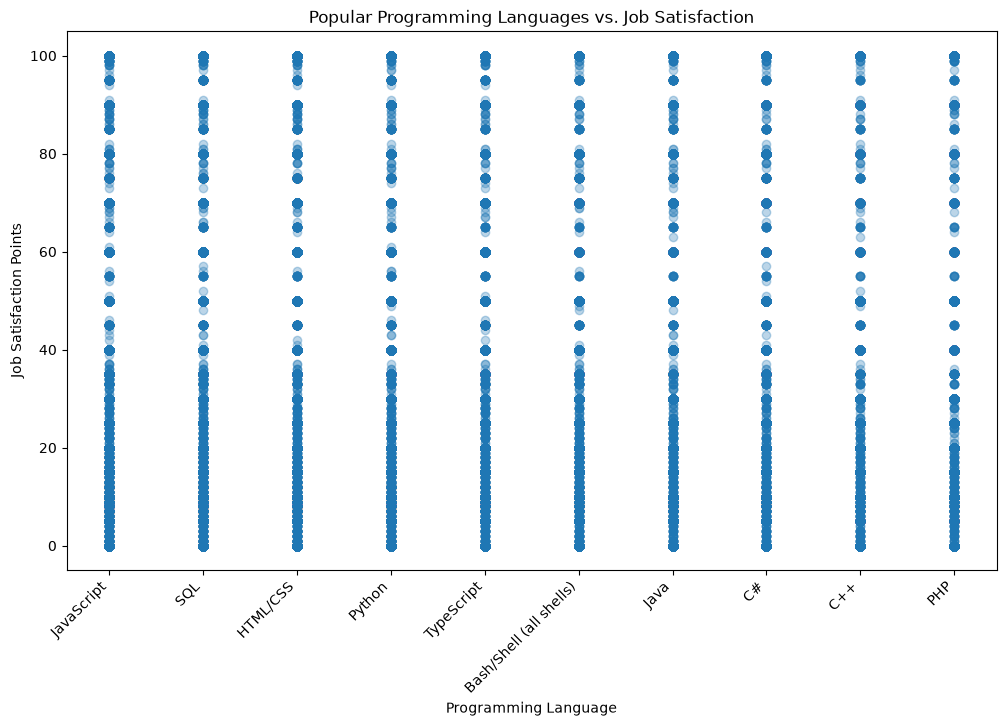

In [8]:
## Write your code here
# Select required columns
language_data = df[
    [
        "LanguageHaveWorkedWith",
        "JobSatPoints_6"
    ]
].dropna()

# Split multiple languages
language_data["Language"] = (
    language_data["LanguageHaveWorkedWith"]
    .str.split(";")
)

# Create one row per language
language_data = language_data.explode(
    "Language"
)

# Remove extra spaces
language_data["Language"] = (
    language_data["Language"]
    .str.strip()
)

# Find the top 10 most popular languages
top_languages = (
    language_data["Language"]
    .value_counts()
    .head(10)
    .index
)

# Keep only top 10 languages
language_data = language_data[
    language_data["Language"].isin(
        top_languages
    )
]

# Create numeric x-axis positions
language_positions = {
    language: i
    for i, language in enumerate(top_languages)
}

language_data["Language_Position"] = (
    language_data["Language"]
    .map(language_positions)
)

# Create scatter plot
plt.figure(figsize=(12, 7))

plt.scatter(
    language_data["Language_Position"],
    language_data["JobSatPoints_6"],
    alpha=0.3
)

plt.xticks(
    range(len(top_languages)),
    top_languages,
    rotation=45,
    ha="right"
)

plt.title(
    "Popular Programming Languages vs. Job Satisfaction"
)

plt.xlabel("Programming Language")
plt.ylabel("Job Satisfaction Points")

plt.show()

### Task 4: Scatter Plot Comparisons Across Groups


#### 1. Scatter Plot for Compensation vs. Job Satisfaction by Employment Type


Visualize the relationship between yearly compensation (`ConvertedCompYearly`) and job satisfaction (`JobSatPoints_6`), categorized by employment type (`Employment`). Use color coding or markers to differentiate between employment types.


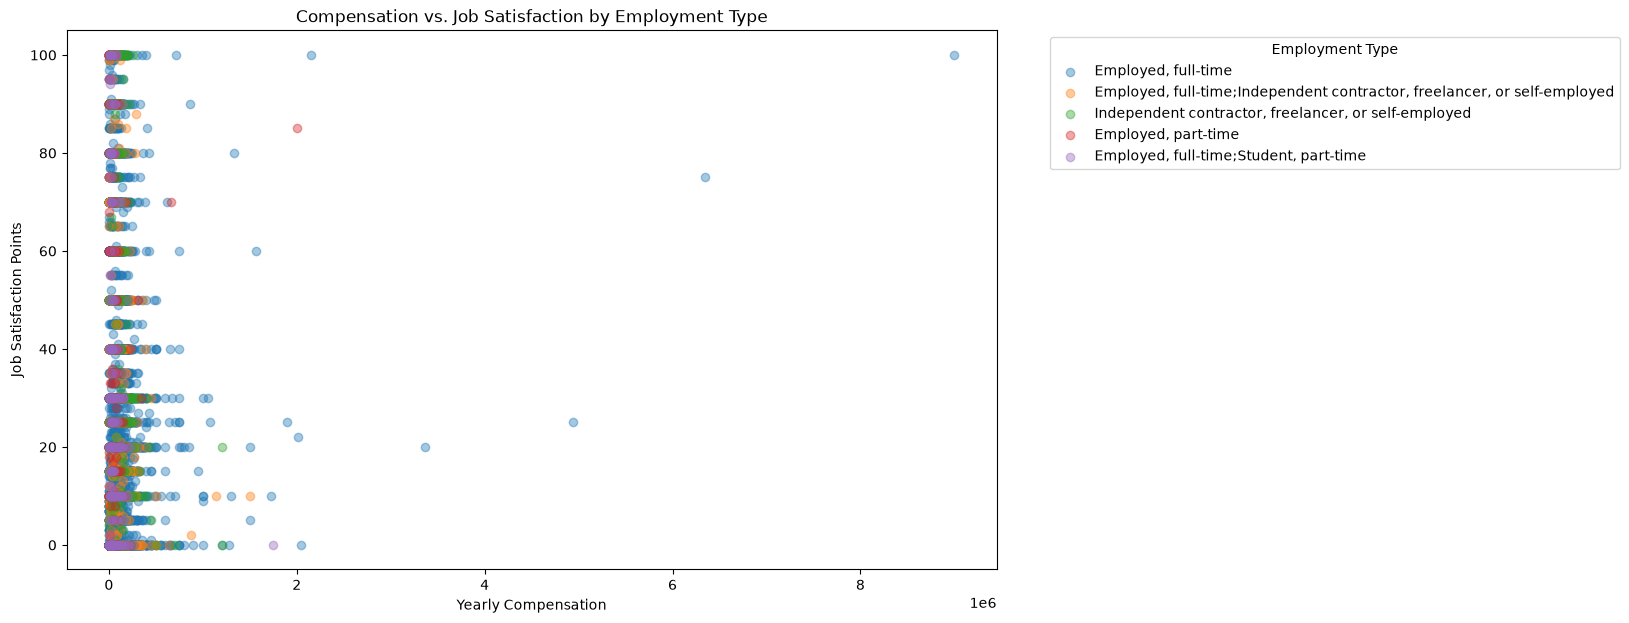

In [9]:
## Write your code here
# Select required columns
employment_data = df[
    [
        "ConvertedCompYearly",
        "JobSatPoints_6",
        "Employment"
    ]
].dropna()

# Find top 5 employment types
top_employment = (
    employment_data["Employment"]
    .value_counts()
    .head(5)
    .index
)

# Keep only top 5
employment_data = employment_data[
    employment_data["Employment"].isin(
        top_employment
    )
]

# Create scatter plot
plt.figure(figsize=(12, 7))

# Plot each employment type separately
for employment in top_employment:

    group = employment_data[
        employment_data["Employment"] == employment
    ]

    plt.scatter(
        group["ConvertedCompYearly"],
        group["JobSatPoints_6"],
        alpha=0.4,
        label=employment
    )

plt.title(
    "Compensation vs. Job Satisfaction by Employment Type"
)

plt.xlabel("Yearly Compensation")
plt.ylabel("Job Satisfaction Points")

plt.legend(
    title="Employment Type",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.show()

#### 2. Scatter Plot for Work Experience vs. Age Group by Country


Compare work experience (`YearsCodePro`) across different age groups (`Age`) and countries (`Country`). Use colors to represent different countries and markers for age groups.


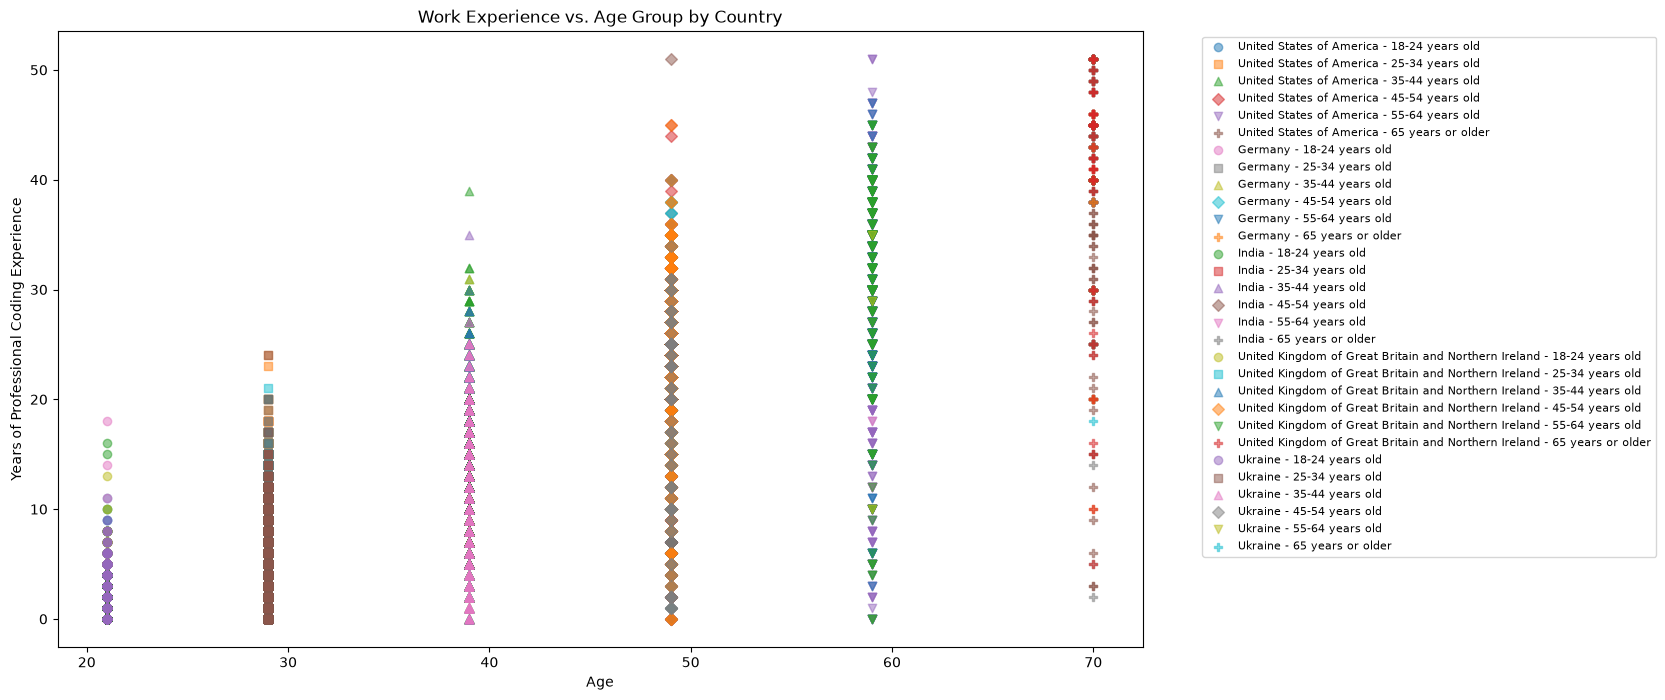

In [10]:
## Write your code here
# Select required columns
country_data = df[
    [
        "Age",
        "Age_numeric",
        "YearsCodePro_numeric",
        "Country"
    ]
].dropna()

# Find top 5 countries
top_countries = (
    country_data["Country"]
    .value_counts()
    .head(5)
    .index
)

# Keep only top 5 countries
country_data = country_data[
    country_data["Country"].isin(
        top_countries
    )
]

# Age groups to display
age_groups = [
    "18-24 years old",
    "25-34 years old",
    "35-44 years old",
    "45-54 years old",
    "55-64 years old",
    "65 years or older"
]

# Marker styles for age groups
markers = [
    "o",
    "s",
    "^",
    "D",
    "v",
    "P"
]

marker_map = dict(
    zip(age_groups, markers)
)

# Create scatter plot
plt.figure(figsize=(14, 8))

# Plot each country and age group
for country in top_countries:

    for age_group in age_groups:

        group = country_data[
            (country_data["Country"] == country) &
            (country_data["Age"] == age_group)
        ]

        if len(group) > 0:

            plt.scatter(
                group["Age_numeric"],
                group["YearsCodePro_numeric"],
                marker=marker_map[age_group],
                alpha=0.5,
                label=f"{country} - {age_group}"
            )

plt.title(
    "Work Experience vs. Age Group by Country"
)

plt.xlabel("Age")
plt.ylabel(
    "Years of Professional Coding Experience"
)

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc="upper left",
    fontsize=8
)

plt.show()

### Final Step: Review


With these scatter plots, you will have analyzed data relationships across multiple dimensions, including compensation, job satisfaction, employment types, and demographics, to uncover meaningful trends in the developer community.


### Summary


After completing this lab, you will be able to:
- Analyze how numerical variables relate across specific groups, such as employment types and countries.
- Use scatter plots effectively to represent multiple variables with color, size, and markers.
- Gain insights into compensation, satisfaction, and demographic trends using advanced scatter plot techniques.


## Authors:
Ayushi Jain


### Other Contributors:
- Rav Ahuja
- Lakshmi Holla
- Malika


<!--## Change Log
|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|               
|2024-10-07|1.2|Madhusudan Moole|Reviewed and updated lab|                                                                                      
|2024-10-06|1.0|Raghul Ramesh|Created lab|-->


Copyright © IBM Corporation. All rights reserved.
